# Predicting Stellar Class from Data

This notebook records exploratory analysis for the Predicting Stellar Class challenge, a kaggle competition using synthetic data based on observational data. The synthetic data are published on kaggle:

Yao Yan, Walter Reade, Elizabeth Park. Predicting Stellar Class. https://kaggle.com/competitions/playground-series-s6e6, 2026. Kaggle.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

100%|██████████████████████████████████████████████████████████████| 58.6M/58.6M [19:52<00:00, 51.5kB/s]

Extracting files...


Path to competition files: /Users/jaquesgillis/.cache/kagglehub/competitions/playground-series-s6e6


In [13]:
from setup import * 
import os

os.listdir(path)

['test.csv', 'train.csv', 'sample_submission.csv']

In [17]:
df = pd.read_csv(path + '/train.csv')

In [18]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


Most of these columns represent filter types. But we also have redshift of the observed body, spectral type, and galaxy population.

### Spectral types

The spectral types may be the most useful data for classifying our objects. These encode the observed absorption lines and inferred temperature and composition of the body using the Harvard Classification Scheme. The temperatures shown in the table below are taken from http://www.star.ucl.ac.uk/~pac/spectral_classification.html by Jesse S. Allen. 

| O | B | A | F | G | K | M | 
| --- | --- | --- | --- | --- | --- | --- |
| over 25,000K | 11,000-25,000K | 7,500-11,000K | 6,000-7,500K | 5,000-6,000K | 3,500-5,000K | under 3,500K |

We should expect stars and quasars to have significantly different spectral types. Galaxies, which of course are composed of many different kinds of stars as well as cooler bodies, should also have distinct spectral types. 

To start our exploration, we'll look at the frequencies of the classes of bodies by spectral type.

In [86]:
celestial_categories = df['class'].unique().tolist()

In [87]:
spectral_types = df['spectral_type'].unique().tolist()

In [88]:
galaxy_populations = df['galaxy_population'].unique().tolist()

In [89]:
print(*spectral_types)
print(*galaxy_populations)

M O/B G/K A/F
Red_Sequence Blue_Cloud


In [90]:
celestial_categories

['GALAXY', 'QSO', 'STAR']

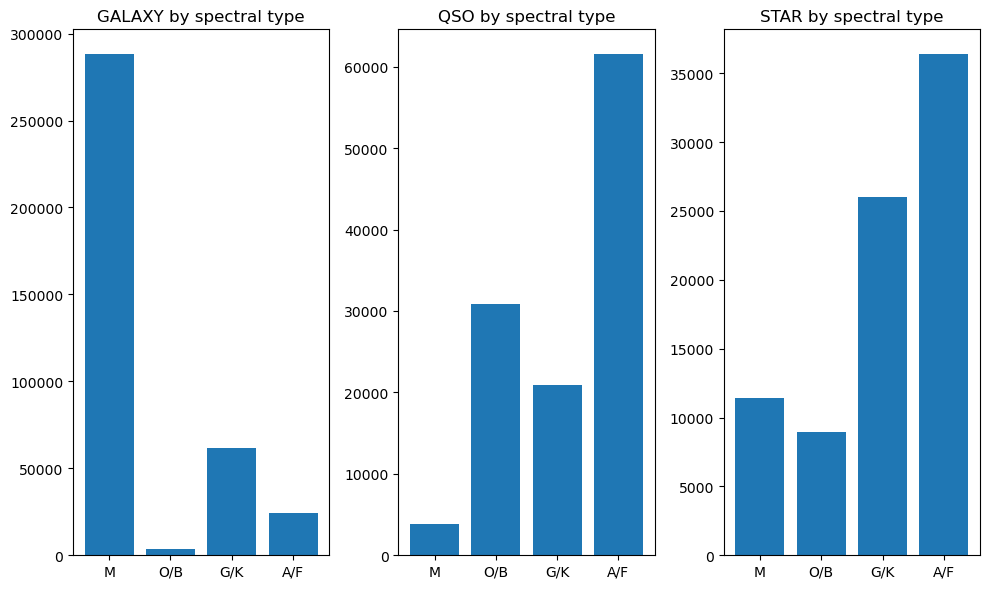

In [92]:
# Bar chart of classes for spectral type

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for category in celestial_categories:
    ax = next(axes_iterator)
    freq_by_spectral = [len(df[ (df['class'] == category) & (df['spectral_type'] == spectral_type) ]) for spectral_type in spectral_types]
    ax.bar(spectral_types, freq_by_spectral)
    ax.set_title(f"{category} by spectral type")

plt.tight_layout()
plt.show()

### Spectral type distribution analysis

The frequency of GALAXY is much higher for M than for the other spectral types.
Quasars and stars actually have similar distributions. In particular, they are both far more likely to have A/F spectral type than any other. Quasars are more likely to have type O/B than stars, and stars are more likely to have type M than quasars--but these differences are dwarfed by the similarities. 

Perhaps further dividing the data by redshift could help. Let's take a look at the redshift distributions.

In [98]:
# First, just look at simple distribution statistics for redshift for each class of body.

for category in celestial_categories:
    print(f"redshift distribution for {category}")
    print(df[ df['class'] == category ]['redshift'].describe())
    print('\n')
    

redshift distribution for GALAXY
count    377480.000000
mean          0.509026
std           0.309139
min          -0.009934
25%           0.267017
50%           0.481960
75%           0.715023
max           6.860273
Name: redshift, dtype: float64


redshift distribution for QSO
count    117143.000000
mean          1.875641
std           1.069731
min           0.000100
25%           1.131805
50%           1.798886
75%           2.506401
max           7.010780
Name: redshift, dtype: float64


redshift distribution for STAR
count    82724.000000
mean         0.068115
std          0.064476
min         -0.009970
25%          0.021884
50%          0.056492
75%          0.102069
max          5.445217
Name: redshift, dtype: float64




The redshifts are quite a bit higher for quasars than for stars, perhaps reflecting greater distance from Earth. The distributions for stars and quasars hardly overlap, making this a useful metric. 

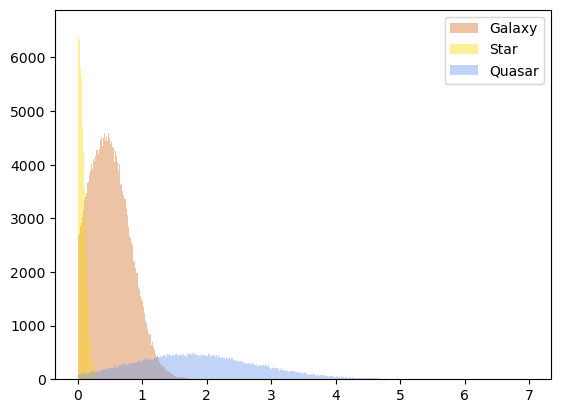

In [123]:
# Let's compare them graphically

galaxy_shifts = [*df[ df['class'] == 'GALAXY' ]["redshift"]]
star_shifts = [*df[ df['class'] == 'STAR' ]["redshift"]]
qso_shifts = [*df[ df['class'] == 'QSO' ]["redshift"]]
shift_bins = np.arange(0.0, 7.0, 0.01)

fig, ax = plt.subplots()
ax.hist(galaxy_shifts, bins=shift_bins, color="chocolate", alpha=0.4, label="Galaxy")
ax.hist(star_shifts, bins=shift_bins, color="gold", alpha=0.4, label="Star")
ax.hist(qso_shifts, bins=shift_bins, color="cornflowerblue", alpha=0.4, label="Quasar")

ax.legend()
plt.show()

### Comparative distributions of filter types

Below we select each target value and plot the distribution for each filter type. 

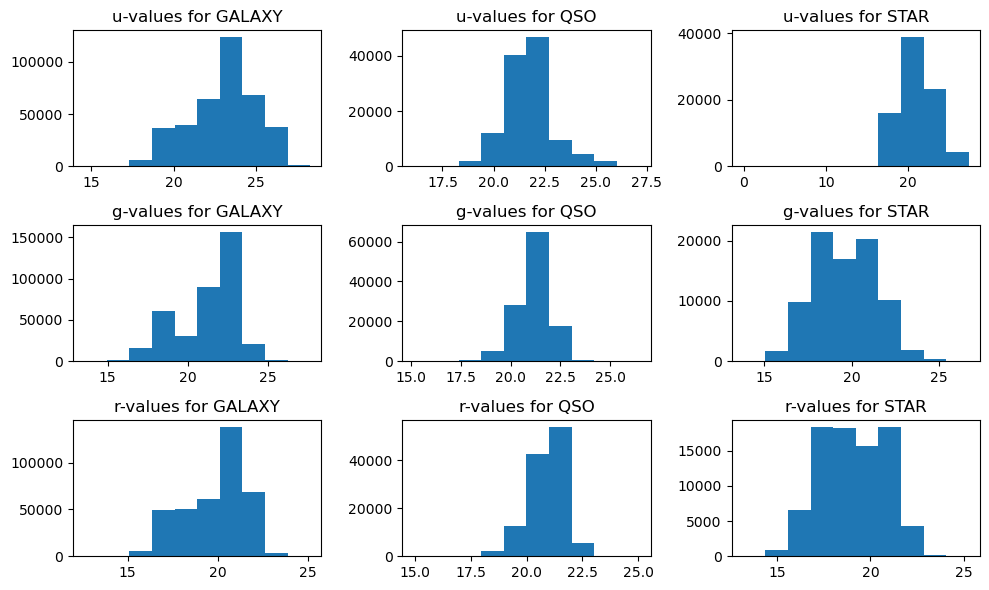

In [30]:
# Compare the stellar classes in each filter type.

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat
for filter in ['u', 'g', 'r']:
    for i, category in enumerate(celestial_categories):
        ax = next(axes_iterator)  
        ax.hist(df[df['class'] == category][filter])
        ax.set_title(f"{filter}-values for {category}")
    
plt.tight_layout()
plt.show()
    

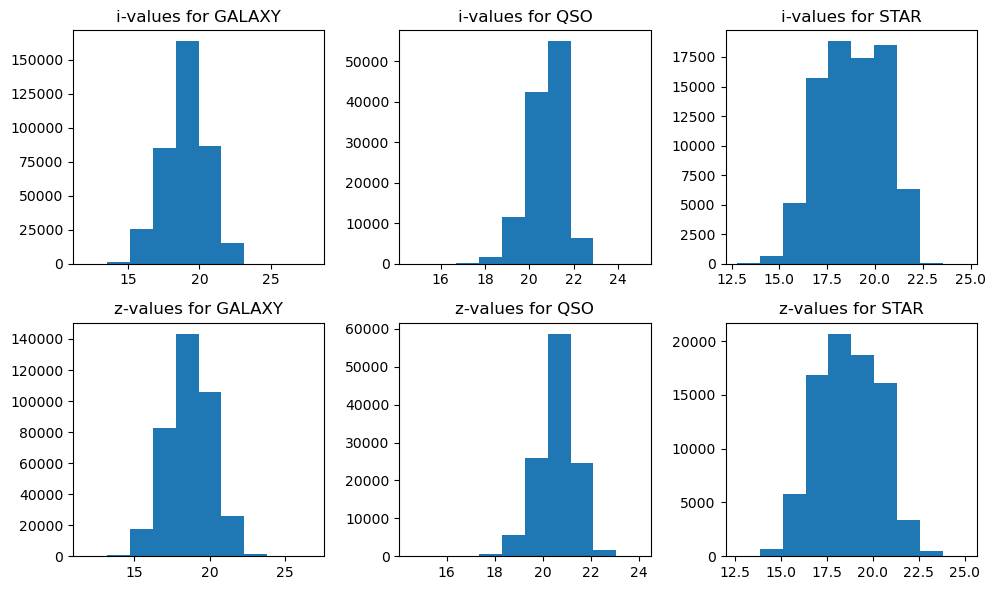

In [31]:
# Compare the stellar classes in each filter type.

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat
for filter in ['i', 'z']:
    for i, category in enumerate(celestial_categories):
        ax = next(axes_iterator)  
        ax.hist(df[df['class'] == category][filter])
        ax.set_title(f"{filter}-values for {category}")
    
plt.tight_layout()
plt.show()
    

### Comments

There is a lot of overlap between these distributions. The only really separate distribution is that of the u-values for stars. There appears to be less variability in all filtered spectral values for quasars than the other two stellar types, and perhaps the most in stars. 

### Average values for classes

For each class, find the average value for each filter, and plot them together.

In [49]:
# Create a dictionary containing dictionaries of filter averages 
# for each spectral class

class_averages = dict()
for category in celestial_categories:
    class_averages[category] = dict()
    print(type(class_averages[category]))
    for filter_type in ['u', 'g', 'r', 'i', 'z']:
        class_averages[category][filter_type] = df[df['class'] == category][filter_type].mean()


<class 'dict'>
<class 'dict'>
<class 'dict'>


In [50]:
class_averages['GALAXY']

{'u': np.float64(22.989160246429492),
 'g': np.float64(21.27014683927634),
 'r': np.float64(19.860511362981434),
 'i': np.float64(19.06822162861978),
 'z': np.float64(18.629897173762956)}

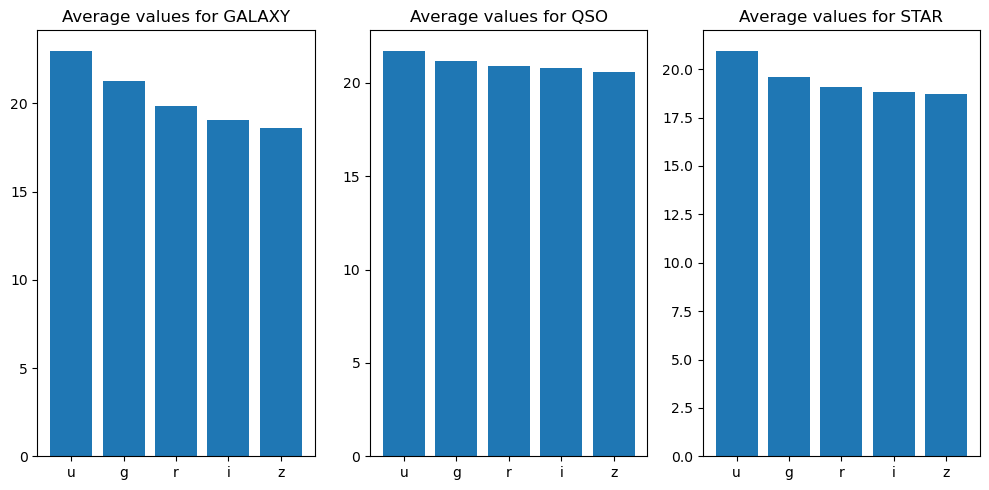

In [56]:
# Plot bar charts of these averages

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for category, observations in class_averages.items():
    ax = next(axes_iterator)
    keys = [key for key, value in observations.items()]
    values = [value for key, value in observations.items()]
    ax.bar(keys, values)
    ax.set_title(f"Average values for {category}")
    
plt.tight_layout()
plt.show()
    

In [61]:
# Check the standard deviations

for category in celestial_categories:
    for filter_type in ['u', 'g', 'r', 'i', 'z']:
        print(f"The standard deviation of {filter_type} in class {category}: {df[df['class'] == category][filter_type].std()}")

The standard deviation of u in class GALAXY: 1.9967690098347732
The standard deviation of g in class GALAXY: 1.8759150684960988
The standard deviation of r in class GALAXY: 1.6900319862816804
The standard deviation of i in class GALAXY: 1.4996622755382432
The standard deviation of z in class GALAXY: 1.4426092014811225
The standard deviation of u in class QSO: 1.1506950712282888
The standard deviation of g in class QSO: 0.8253291288124336
The standard deviation of r in class QSO: 0.7948615063935403
The standard deviation of i in class QSO: 0.7923210786442781
The standard deviation of z in class QSO: 0.7866909228930358
The standard deviation of u in class STAR: 2.0166878296148005
The standard deviation of g in class STAR: 1.7666767192108588
The standard deviation of r in class STAR: 1.708942948421379
The standard deviation of i in class STAR: 1.6739106480617576
The standard deviation of z in class STAR: 1.6771088649765458


In [65]:
# Compare to cross-class average distances, starting from 
# the right, where differences appear greatest

print(f"The difference between average z-values for stars and quasars is: {df[df['class'] == 'STAR']['z'].mean() - df[df['class'] == 'QSO']['z'].mean()}")
print(f"The difference between average z-values for quasars and galaxies is: {df[df['class'] == 'QSO']['z'].mean() - df[df['class'] == 'GALAXY']['z'].mean()}")
print(f"The difference between average i-values for stars and quasars is: {df[df['class'] == 'STAR']['i'].mean() - df[df['class'] == 'QSO']['i'].mean()}")
print(f"The difference between average i-values for quasars and galaxies is: {df[df['class'] == 'QSO']['i'].mean() - df[df['class'] == 'GALAXY']['i'].mean()}")


The difference between average z-values for stars and quasars is: -1.8949598133716918
The difference between average z-values for quasars and galaxies is: 1.9722421881221344
The difference between average i-values for stars and quasars is: -1.9367544649495123
The difference between average i-values for quasars and galaxies is: 1.6990878560947635


### Comments

The variability is indeed lower for quasars than the other types. The variability for stars is a little higher, but not significantly. The z-values and i-values by themselves should differentiate between the classes with some accuracy.